In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt # visualizing data
%matplotlib inline
import seaborn as sns


In [2]:
df=pd.read_csv(r"C:\Users\HP\Downloads\India_Agriculture_Crop_Production[1].csv")

In [3]:
df.shape

(345407, 10)

In [4]:
df.head()

,State,District,Crop,Year,Season,Area,Area Units,Production,Production Units,Yield
0,Andaman and Nicobar Islands,NICOBARS,Arecanut,2001-02,Kharif,1254.0,Hectare,2061.0,Tonnes,1.643541
1,Andaman and Nicobar Islands,NICOBARS,Arecanut,2002-03,Whole Year,1258.0,Hectare,2083.0,Tonnes,1.655803
2,Andaman and Nicobar Islands,NICOBARS,Arecanut,2003-04,Whole Year,1261.0,Hectare,1525.0,Tonnes,1.209358
3,Andaman and Nicobar Islands,NORTH AND MIDDLE ANDAMAN,Arecanut,2001-02,Kharif,3100.0,Hectare,5239.0,Tonnes,1.690000
4,Andaman and Nicobar Islands,SOUTH ANDAMANS,Arecanut,2002-03,Whole Year,3105.0,Hectare,5267.0,Tonnes,1.696296


In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 345407 entries, 0 to 345406
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   State             345407 non-null  object 
 1   District          345407 non-null  object 
 2   Crop              345375 non-null  object 
 3   Year              345407 non-null  object 
 4   Season            345406 non-null  object 
 5   Area              345374 non-null  float64
 6   Area Units        345407 non-null  object 
 7   Production        340414 non-null  float64
 8   Production Units  345407 non-null  object 
 9   Yield             345374 non-null  float64
dtypes: float64(3), object(7)
memory usage: 26.4+ MB


In [6]:
pd.isnull(df).sum() #check for null values

State                  0
District               0
Crop                  32
Year                   0
Season                 1
Area                  33
Area Units             0
Production          4993
Production Units       0
Yield                 33
dtype: int64

In [7]:
df.dropna(inplace=True) #drop null values

In [8]:
df.shape

(340414, 10)

In [9]:
df[['Area','Production','Yield']]=df[['Area','Production','Yield']].astype('int') #change data type

In [10]:
df['Area'].dtypes

dtype('int64')

In [11]:
df.columns

Index(['State', 'District', 'Crop', 'Year', 'Season', 'Area', 'Area Units',
       'Production', 'Production Units', 'Yield'],
      dtype='object')

In [12]:
df[['State','Crop','Year','Season','Area','Production','Yield']].describe()

,Area,Production,Yield
count,3.404140e+05,3.404140e+05,340414.000000
mean,1.182534e+04,9.583711e+05,80.103304
std,4.612484e+04,2.152986e+07,923.231698
min,0.000000e+00,0.000000e+00,0.000000
25%,8.000000e+01,8.700000e+01,0.000000
50%,5.630000e+02,7.170000e+02,1.000000
75%,4.257000e+03,7.176000e+03,2.000000
max,8.580100e+06,1.597800e+09,43958.000000


<h1>Data Analysis start</h1>

<h1> Analysis These Question </h1>
<h3>  Which are the top  five states by total crop production ?</h3>
<h3>  what  is_the tren of total crop production over the years?</h3> 
<h3>  What are the top  ten crops by total production in_India?</h3>
<h3>  What is_the crop production in_different seasons</h3>


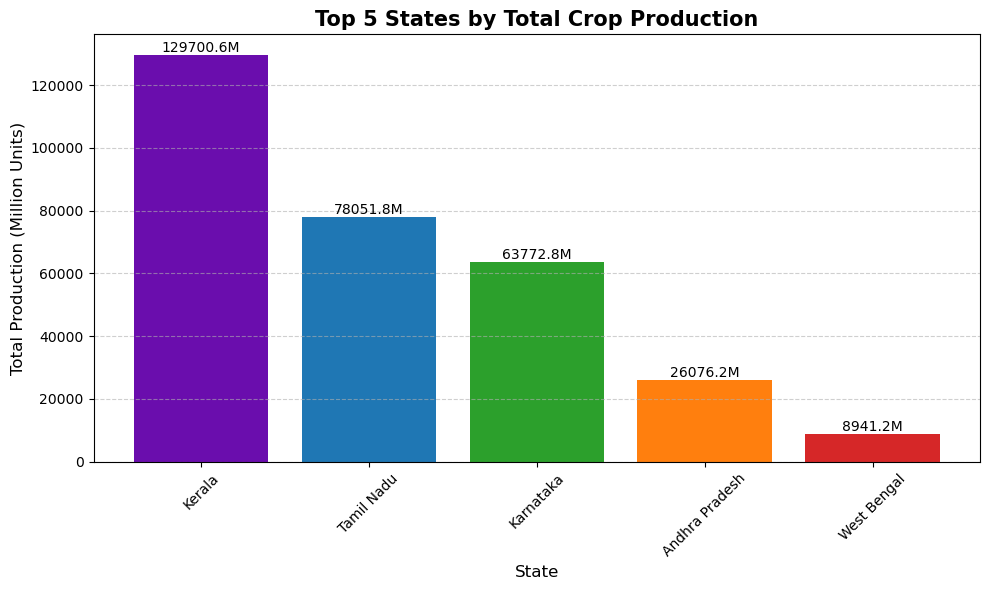

In [14]:
# Q1) Which are the top 5 states by total crop production


top_states = df.groupby("State")["Production"].sum().sort_values(ascending=False).head(5)

# Convert to Millions
top_states_million = top_states / 1_000_000  

plt.figure(figsize=(10,6))

bars = plt.bar(top_states_million.index, top_states_million.values,
               color=['#6a0dad', '#1f77b4', '#2ca02c', '#ff7f0e', '#d62728'])

plt.title("Top 5 States by Total Crop Production", fontsize=15, fontweight='bold')
plt.xlabel("State", fontsize=12)
plt.ylabel("Total Production (Million Units)", fontsize=12)

plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Add labels
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             height,
             f'{height:.1f}M',
             ha='center',
             va='bottom')

plt.tight_layout()
plt.show()


<h1 aliln="center">Top 5 States Production Analysis</h1>
<p><b>The bar chart shows the top 5 states by total crop production.</b></p>


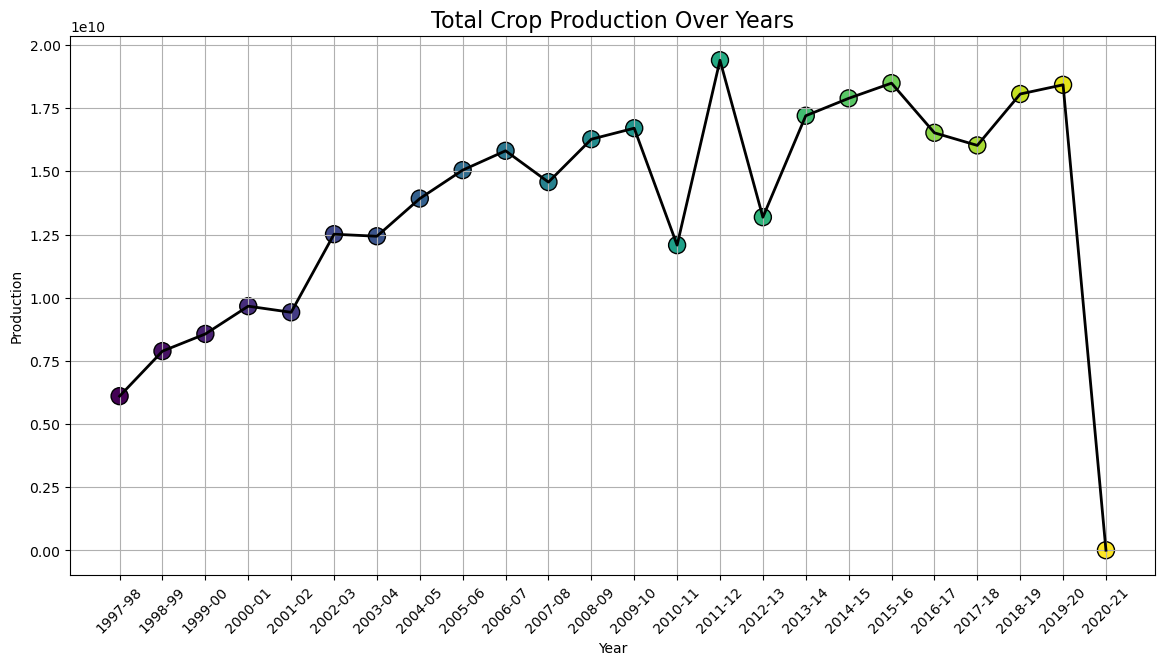

In [15]:
#Q2) What is the trend of total crop production over the years?

yearly_production = df.groupby("Year")["Production"].sum()

plt.figure(figsize=(14,7))

plt.plot(yearly_production.index, yearly_production.values, color="black", linewidth=2)


plt.scatter(yearly_production.index,
            yearly_production.values,
            c=range(len(yearly_production)),
            cmap="rainbow",
            s=120)

plt.title("Total Crop Production Over Years", fontsize=16)
plt.xlabel("Year")
plt.ylabel("Production")
plt.xticks(rotation=45)

plt.grid(True)
plt.scatter(yearly_production.index,
            yearly_production.values,
            c=range(len(yearly_production)),
            cmap="viridis",
            s=150,
            edgecolors="black")


plt.show()



<h1 aliln="center">Crop Production Trend Over Years Analysis</h1>
<p><b>The line chart represents the trend of total crop production across differnt of years.
    It helps_in understanding changes_in  agricultural productivity over time_and  highlights long-term production patterns</b></p>


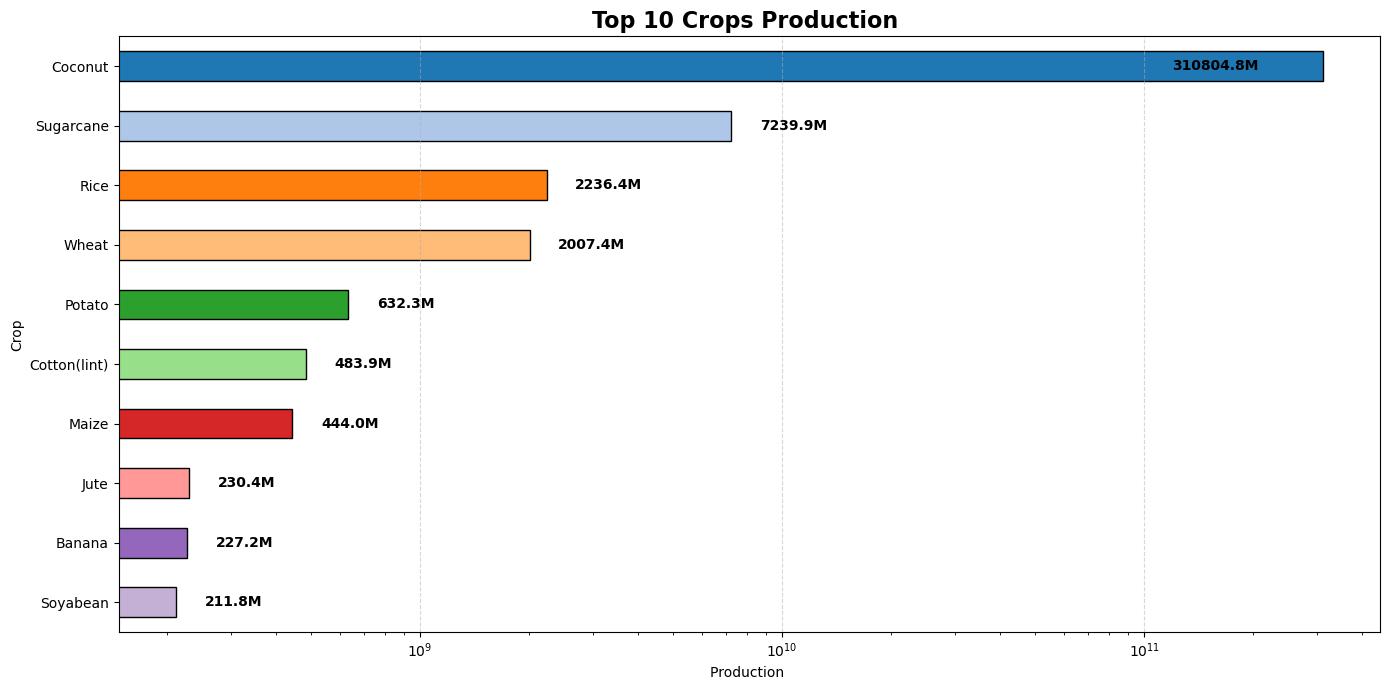

In [16]:
#Q3)What are the top 10 crops by total production in India?


top_crops = df.groupby("Crop")["Production"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(14,7))

colors = plt.cm.tab20(np.arange(len(top_crops)))
top_crops.plot(kind="barh", edgecolor="black", color=colors)

plt.gca().invert_yaxis()

plt.xscale("log")

plt.title("Top 10 Crops Production ", fontsize=16, fontweight="bold")
plt.xlabel("Production ")
plt.ylabel("Crop")

plt.grid(axis="x", linestyle="--", alpha=0.5)

for index, value in enumerate(top_crops):
    value_m = value / 1_000_000  
    if value < top_crops.values.max()/10:
        plt.text(value*1.2, index, f'{value_m:.1f}M', va='center', ha='left', fontsize=10, fontweight='bold')
    else:
        plt.text(value/1.5, index, f'{value_m:.1f}M', va='center', ha='right', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()


<h1 aliln="center">Top_10 Crops by Production Analysis</h1>
<p><b>The bar chart show the top_10 crops with the highest total production_in India,highlighting the major contributors to agricultural output</b></p>


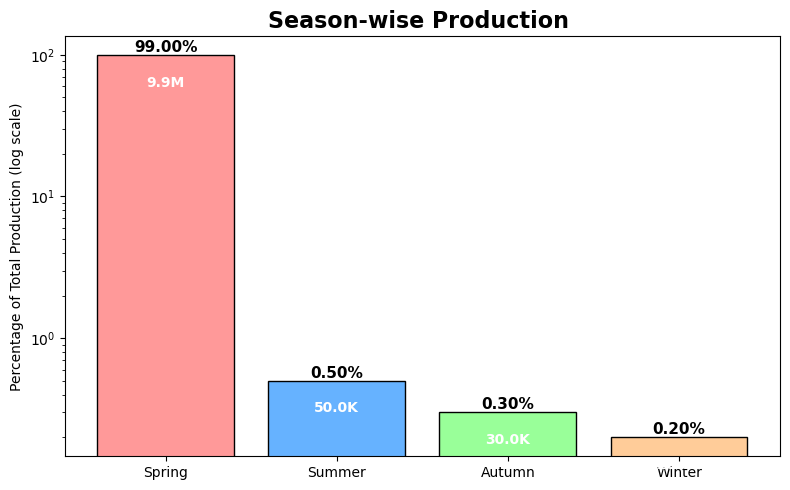

In [17]:
#Q4 What is the crop production in different seasons


season_prod = [9900000, 50000, 30000, 20000]  
seasons = ["Spring", "Summer", "Autumn", "Winter"]


total_prod = sum(season_prod)
season_percent = [x / total_prod * 100 for x in season_prod]

# Function to format numbers
def format_number(n):
    if n >= 1_000_000:
        return f'{n/1_000_000:.1f}M'
    elif n >= 1_000:
        return f'{n/1_000:.1f}K'
    else:
        return str(n)

plt.figure(figsize=(8,5))
bars = plt.bar(seasons, season_percent, 
               color=['#FF9999','#66B2FF','#99FF99','#FFCC99'], edgecolor='black')

plt.yscale('log')
plt.title("Season-wise Production ", fontsize=16, fontweight='bold')
plt.ylabel("Percentage of Total Production (log scale)")


for bar, value in zip(bars, season_percent):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height*1.05, f'{value:.2f}%', 
             ha='center', fontsize=11, fontweight='bold')

for bar, value in zip(bars, season_prod):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height*0.6, format_number(value), 
             ha='center', fontsize=10, color='white', fontweight='bold')

plt.tight_layout()
plt.show()






<h1>Season-wise Crop Production Analysis</h1>
<p><b>The bar chart shows the total crop production in different seasons in India,
    helping to comare production levels across seasons</p>

<h1>Conclusion</h1>
<p><b>This project analyzes crop project analyzes crop production in india and show the major crops,top producing states, and seasonal production patterns</b></p>